# IMDb Rating, Genre, Gross and Star acters Analysis


## Overview

This notebook examines the relationships and correlations between IMDb Rating, Genre, Gross, and Star Actors, aiming to identify trends and patterns using the IMDb Top 1000 Movies dataset.

The target variables in this analysis include `IMDB_Rating`, `Genre`, `Gross`, `Star1`, `Star2`, `Star3`, and `Star4`.

To answer these questions, we will:

* Find and handle missing values
* Classify the data
* Compare the data
* Visualize the results


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

## Research Questions

1. Is there a relationship between Genre and IMDb Rating?

2. Is there a relationship between Genre and Gross?

3. Is there a relationship between IMDb Rating and Gross?

4. Which Star appears most frequently in the Genre with the highest Gross?


## 1.Data Loading

Load The IMDB Top 1000 Movie Dataset Into a Pandas Dataframe.

In [23]:
df = pd.read_csv("../data/imdb_top_1000.csv.xls")

## 2.Missing Value Analysis

Before Analysis Dataset Investigate Missng Value and Calculate Count and Percetage Missing Value This Dataset.

In [24]:
missing_value_table = pd.DataFrame(
    {
    "Missing Value Count": 
    df[["Gross", "IMDB_Rating", "Genre", "Star1", "Star2", "Star3", "Star4"]]
    .isnull()
    .sum(), 
    "Missing Value Percentage": (
        df[["Gross", "IMDB_Rating", "Genre", "Star1", "Star2", "Star3", "Star4"]]
        .isnull().sum() / len(df)) * 100
    }
)

print(missing_value_table)

             Missing Value Count  Missing Value Percentage
Gross                        169                      16.9
IMDB_Rating                    0                       0.0
Genre                          0                       0.0
Star1                          0                       0.0
Star2                          0                       0.0
Star3                          0                       0.0
Star4                          0                       0.0


## 3.Missing Value Handling

As we can observe, only the `Gross` column contains missing values, and we cannot ignore these values.

So, we analyze the relationship between IMDb Rating and Gross using the available Gross data. According to this relationship, we will estimate and fill the missing values.

**Note:** If the correlation between Gross and IMDb Rating is greater than 0.5, we will consider using this approach to fill the missing values.




### 3.1 Check Correlation

measure correlation for cinfident about solution.

For Check Correlation we need to ignore gross missing value.



In [25]:
w_o_missing_value = df[["IMDB_Rating", "Gross"]].dropna().copy()

w_o_missing_value["IMDB_Rating"] = pd.to_numeric(
    w_o_missing_value["IMDB_Rating"],
    errors="coerce"
)

w_o_missing_value["Gross"] = (
    w_o_missing_value["Gross"]
    .str.replace(",", "", regex=False)
)

w_o_missing_value["Gross"] = pd.to_numeric(
    w_o_missing_value["Gross"],
    errors="coerce"
)

w_o_missing_value = w_o_missing_value.dropna()


pearson = w_o_missing_value["IMDB_Rating"].corr(
    w_o_missing_value["Gross"],
    method="pearson"
    )

spearman = w_o_missing_value["IMDB_Rating"].corr(
    w_o_missing_value["Gross"],
    method="spearman"
    )

print(f"Pearson: {pearson:.3f}")
print(f"Spearman: {spearman:.3f}")

Pearson: 0.096
Spearman: -0.050


#### Visualization

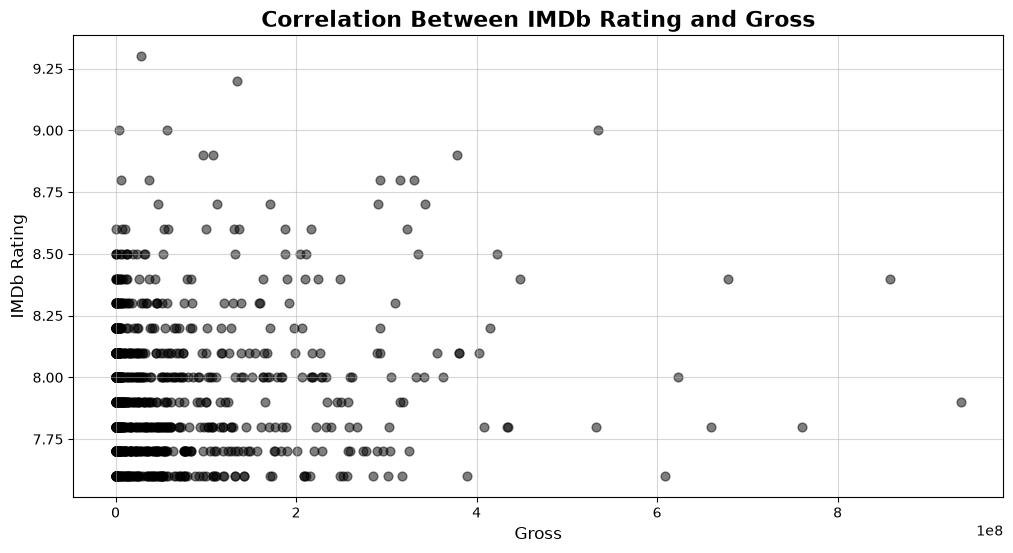

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

w_o_missing_value.plot(
    x="Gross",
    y="IMDB_Rating",
    kind="scatter",
    ax=ax, 
    color="black",
    s=40,
    alpha=0.5
    )

ax.set_title(
    "Correlation Between IMDb Rating and Gross",
    fontsize=16,
    fontweight="bold"
    )

ax.set_xlabel(
    "Gross",
    fontsize=12
    )

ax.set_ylabel(
    "IMDb Rating",
    fontsize=12
    )

plt.grid(True, alpha=0.5)

plt.show()

As we can observe not strong and Reliable Pearson or Spearman Between IMDb Rating and Gross.

But we should sure about this result. 
so we use p-value test and check this relationship available in Population or no.

In [27]:
pearson_r, pearson_p = pearsonr(
    w_o_missing_value["IMDB_Rating"],
    w_o_missing_value["Gross"]
)

spearman_r, spearman_p = spearmanr(
    w_o_missing_value["IMDB_Rating"],
    w_o_missing_value["Gross"]
)

print(f"Pearson: r = {pearson_r:.3f}, p-value = {pearson_p:.3f}")
print(f"Spearman: r = {spearman_r:.3f}, p-value = {spearman_p:.3f}")



Pearson: r = 0.096, p-value = 0.006
Spearman: r = -0.050, p-value = 0.152


Movie ratings do not appear to have a meaningful relationship with gross revenue in this dataset.

We ignore Gross Missing value and start answer the qustion without gross missing value.

In [28]:
original_rows = len(df)
remaining_rows = len(w_o_missing_value)

print(f"Original Rows Count: {original_rows}")
print(f"Remaining Rows Counts: {remaining_rows}")
print(f"Rows Excluded: {original_rows - remaining_rows}")

Original Rows Count: 1000
Remaining Rows Counts: 831
Rows Excluded: 169


## 4. Questions

### 4.1 Qestion:
#### 1) is there a relationship between Genre and IMDb Rating?

We Mesure This Relationship Strenght in Handel Missing value unit and answer This question.

### 4.2 Question:

#### 2) is there a relationship between Genre and Gross?

For This question We answer this question and then grouping Each genre based on its gross and ordered by gross revenue.

#### Data Cleaning

In [29]:
Genres = df["Genre"].str.split(", ", expand=True)

Genres.columns = ["Genre_1", "Genre_2", "Genre_3"]

df = pd.concat([df, Genres], axis=1)


In [30]:
df["Gross"] = pd.to_numeric(
    df["Gross"].str.replace(",", "", regex=False),
    errors="coerce"
)

#### Calculate Gross for Each Genre


In [31]:
each_genre_gross = (
    df[["Genre_1", "Genre_2", "Genre_3", "Gross"]]
    .melt(
        id_vars = "Gross",
        value_vars = ["Genre_1", "Genre_2", "Genre_3"],
        value_name = "Genre"
    )
    .dropna(subset=["Genre"])
    .groupby("Genre", as_index=False)["Gross"].sum()
    .sort_values("Gross", ascending=False)
)

each_genre_gross["Gross_Billion"] = each_genre_gross["Gross"] / 1e9

print(each_genre_gross[["Genre", "Gross_Billion"]])

        Genre  Gross_Billion
1   Adventure      28.174317
6       Drama      27.497623
0      Action      22.033328
4      Comedy      12.247932
16     Sci-Fi       9.029610
2   Animation       8.573824
5       Crime       6.956304
18   Thriller       6.454429
8     Fantasy       6.082543
3   Biography       5.304578
7      Family       4.460768
15    Romance       4.318397
14    Mystery       3.467048
10    History       2.388200
19        War       1.408897
12      Music       1.086350
17      Sport       1.019768
11     Horror       0.880052
20    Western       0.856301
13    Musical       0.282791
9   Film-Noir       0.053593


#### Visualization

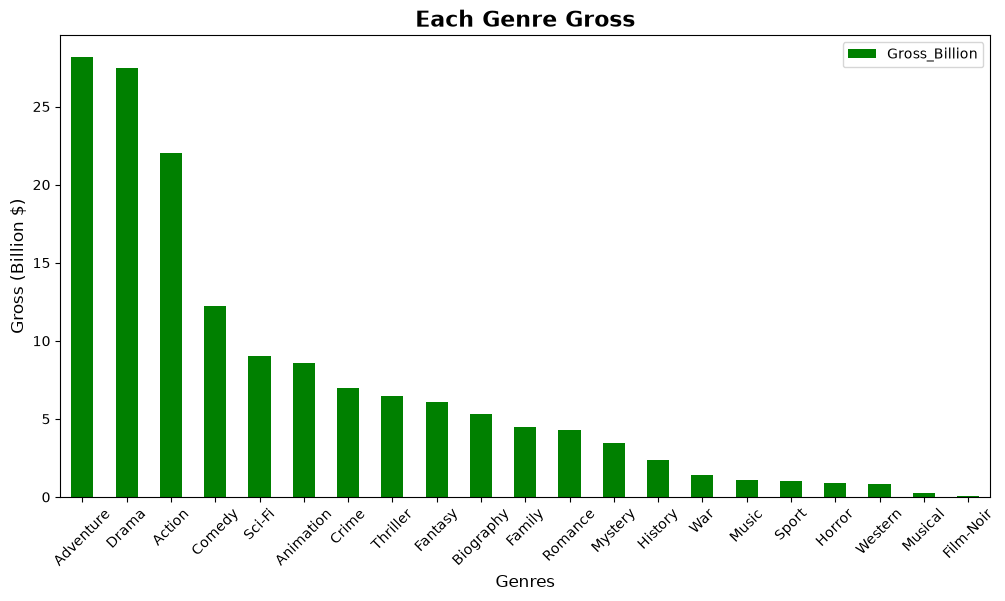

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

each_genre_gross.plot(
    x="Genre",
    y="Gross_Billion",
    kind="bar",
    ax=ax,
    color="green"
)

ax.tick_params(
    axis="x", 
    rotation=45
    )

ax.set_title(
    "Each Genre Gross",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Gross (Billion $)",
    fontsize=12
    )

ax.set_xlabel(
    "Genres",
    fontsize=12
)

plt.show()

as we can see Most Gross genre is Advanture, Drama and Action. 



### 4.3 Question:

### 3) Is there a relationship between IMDb Rating and Gross?


For answer this Question we need Create new datafram, cleaning gross data and check correlation.

Because this dataset Includes 1000 recordes and Includes in the end we binning IMDb Rate and Calculate mean gross for each bins.

#### Data Cleaning

in Previous question we clean Gross data 

We just ignore gross missing value

In [33]:
corr_df = df[["Gross","IMDB_Rating"]].dropna()

#### Check Correlation Between IMDb Rating and Gross

In [34]:
pearson_r_1, pearson_p_1 = pearsonr(
    corr_df["Gross"],
    corr_df["IMDB_Rating"]
)

spearman_r_1, spearman_p_1 = spearmanr(
    corr_df["Gross"],
    corr_df["IMDB_Rating"]
)

print(f"Spearman = r: {spearman_r_1:.3f}, p-value: {spearman_p_1:.3f}")
print(f"Pearson = r: {pearson_r_1:.3f}, p-value: {pearson_p_1:.3f}")

Spearman = r: -0.050, p-value: 0.152
Pearson = r: 0.096, p-value: 0.006


no identify strong correlation between imdb rating and gross also not available High intensity correlation.

#### Visualization

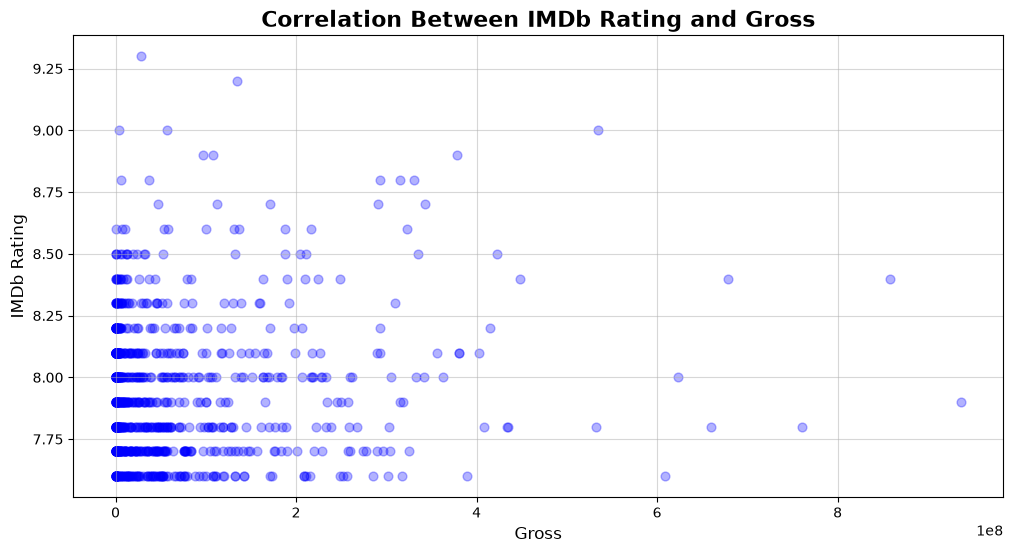

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))


corr_df.plot(
    x="Gross",
    y="IMDB_Rating",
    kind="scatter",
    alpha=0.3,
    ax=ax,
    color="blue",
    s=40
)

ax.set_title(
    "Correlation Between IMDb Rating and Gross",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Gross",
    fontsize=12
)

ax.set_ylabel(
    "IMDb Rating",
    fontsize=12
)

plt.grid(True, alpha=0.5)

plt.show()

#### Binning


for this part we binnig imdb rate by 1 and calculate average gross for each part.

In [36]:
bins = [i for i in range(0, 11, 1)]
labels = [f"{i}-{i+1}" for i in range(0, 10, 1)]

df["imdb_binning"] = pd.cut(
    df["IMDB_Rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [ ]:
gross_average = (
    (df.groupby("imdb_binning")["Gross"]
     .mean()).round(3)
     .reset_index()
     .rename(columns={"Gross": "mean_gross"})
)


print(gross_average)

  imdb_binning    mean_gross
0          7-8  6.608229e+07
1          8-9  7.220287e+07
2         9-10  8.165394e+07


as we can see Whatever imdb rate higher It is inferred gross It increases.

#### Visualization

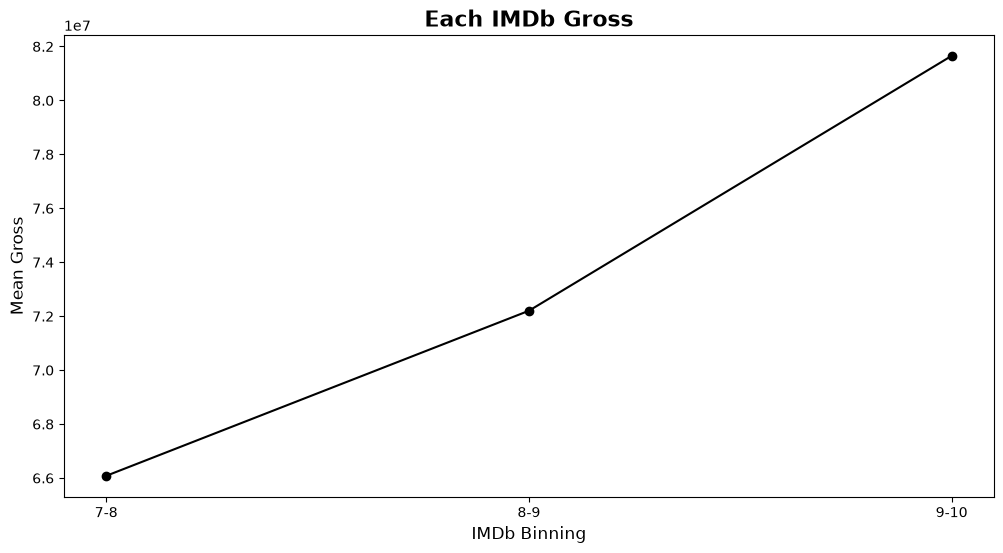

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    gross_average["imdb_binning"],
    gross_average["mean_gross"],
    color="black",
    marker="o"
)

ax.set_title(
    "Each IMDb Gross",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "IMDb Binning",
    fontsize=12
)

ax.set_ylabel(
    "Mean Gross",
    fontsize=12
)

plt.show()

### 4.4 Question:

Which Star appears most frequently in the Genre with the highest Gross?

First we find every genre stars.